# Part 2 — Preprocessing & Data Augmentation

## 3. EDA

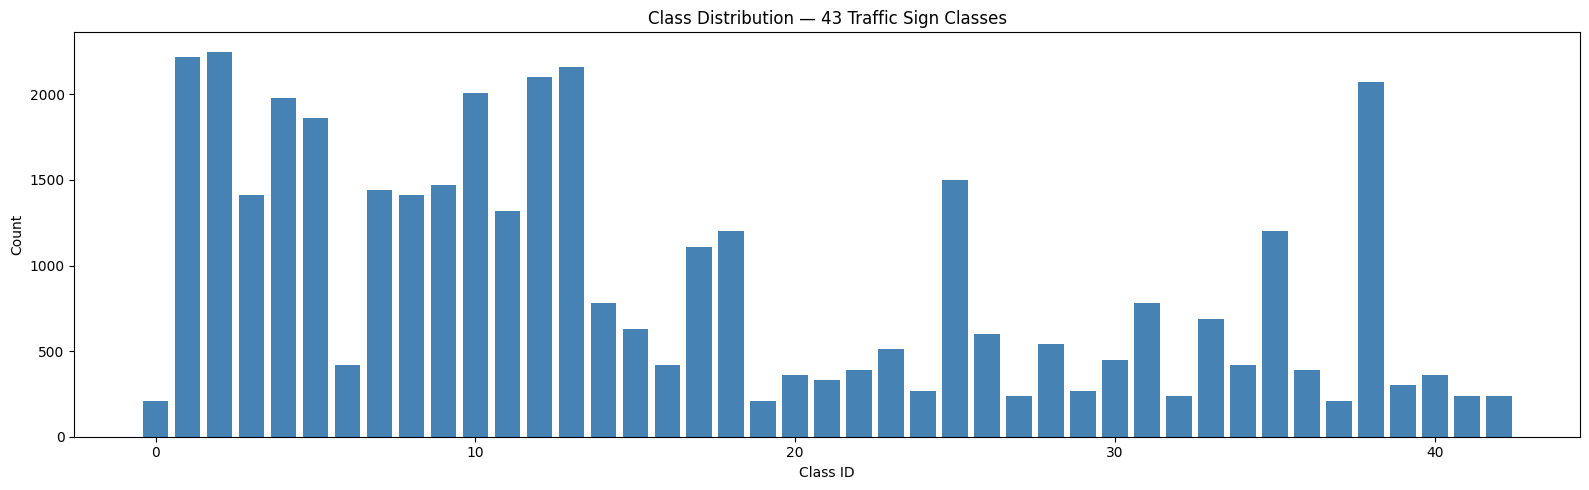

Min: 210 (class 0)  Max: 2250 (class 2)  Ratio: 10x


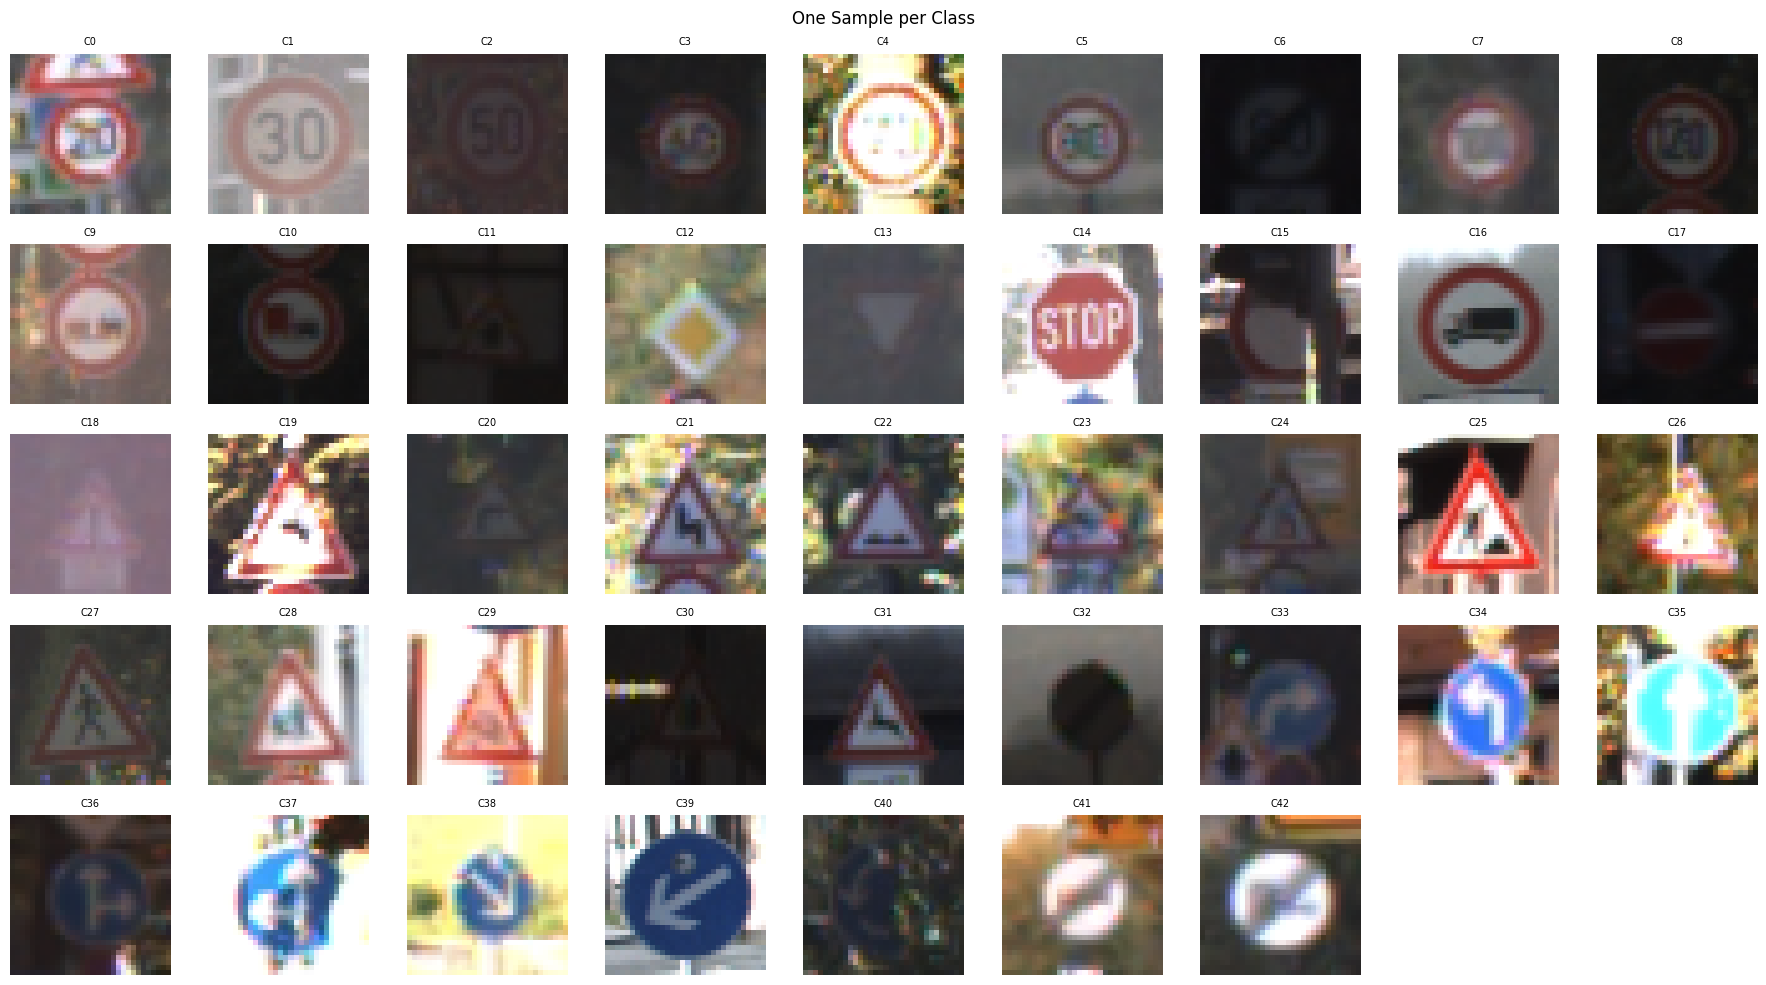

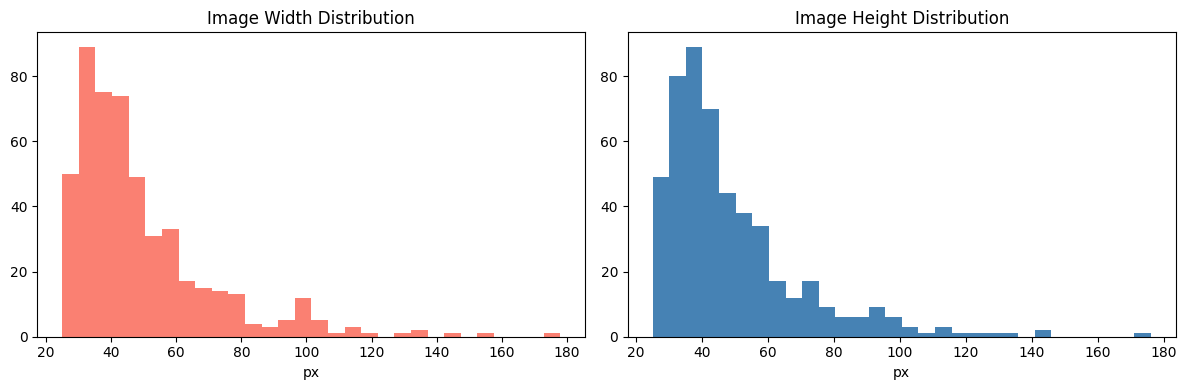

Width  mean:49.3  Height mean:49.0
All images will be resized to 32x32 for training.


In [10]:
counts = train_df['ClassId'].value_counts().sort_index()

plt.figure(figsize=(16,5))
plt.bar(counts.index, counts.values, color='steelblue')
plt.xlabel('Class ID'); plt.ylabel('Count')
plt.title('Class Distribution — 43 Traffic Sign Classes')
plt.tight_layout(); plt.show()

print(f"Min: {counts.min()} (class {counts.idxmin()})  "
      f"Max: {counts.max()} (class {counts.idxmax()})  "
      f"Ratio: {counts.max()//counts.min()}x")

# Sample image per class
fig, axes = plt.subplots(5, 9, figsize=(18,10))
axes = axes.flatten()
for cid in range(43):
    row = train_df[train_df['ClassId']==cid].iloc[0]
    p   = os.path.join(BASE, row['Path'])
    try:
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        axes[cid].imshow(cv2.resize(img,(32,32)))
    except: pass
    axes[cid].set_title(f'C{cid}', fontsize=7)
    axes[cid].axis('off')
for i in range(43, len(axes)): axes[i].set_visible(False)
plt.suptitle('One Sample per Class', fontsize=12)
plt.tight_layout(); plt.show()

# Image size distribution
sample = train_df.sample(500, random_state=42)
widths, heights = [], []
for _, row in sample.iterrows():
    img = cv2.imread(os.path.join(BASE, row['Path']))
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(widths,  bins=30, color='salmon')
axes[0].set_title('Image Width Distribution'); axes[0].set_xlabel('px')
axes[1].hist(heights, bins=30, color='steelblue')
axes[1].set_title('Image Height Distribution'); axes[1].set_xlabel('px')
plt.tight_layout(); plt.show()
print(f"Width  mean:{np.mean(widths):.1f}  Height mean:{np.mean(heights):.1f}")
print("All images will be resized to 32x32 for training.")

## 4. Load All Images

In [11]:
NUM_CLASSES = 43

def load_images(df, base, size=32):
    X, y = [], []
    for _, row in df.iterrows():
        p = os.path.join(base, row['Path'])
        try:
            img = cv2.imread(p)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (size, size))
            X.append(img)
            y.append(int(row['ClassId']))
        except: pass
    return np.array(X, dtype=np.float32)/255.0, np.array(y, dtype=np.int32)

print("Loading train 32x32..."); X_all32, y_all32 = load_images(train_df, BASE, 32)
print("Loading test  32x32..."); X_test32, y_test32 = load_images(test_df, BASE, 32)
print("Loading train 48x48..."); X_all48, y_all48 = load_images(train_df, BASE, 48)
print("Loading test  48x48..."); X_test48, y_test48 = load_images(test_df, BASE, 48)

print(f"\nX_all32 : {X_all32.shape}  range [{X_all32.min():.2f},{X_all32.max():.2f}]")
print(f"X_test32: {X_test32.shape}")
print(f"X_all48 : {X_all48.shape}")

Loading train 32x32...
Loading test  32x32...
Loading train 48x48...
Loading test  48x48...

X_all32 : (39209, 32, 32, 3)  range [0.00,1.00]
X_test32: (12630, 32, 32, 3)
X_all48 : (39209, 48, 48, 3)
